# Summative Lab: Forest Fires Prevention

## Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo

forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets

# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


## Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [3]:
# IMPORTS

# DATA MANIPULATION
import pandas as pd
import numpy as np

# DATA VISUALIZATION
import matplotlib.pyplot as plt

# STATISTICAL VISUALIZATION
import scipy.stats as stats

# TRAIN / TEST SPLITTING
from sklearn.model_selection import train_test_split

# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

# REGRESSION MODELS
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression,

)

# REGRESSION METRICS
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
     root_mean_squared_error,
     mean_absolute_error
)

# CLASSIFICATION METRICS
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# STATSMODELS (OLS REGRESSION & DIAGNOSTICS)
import statsmodels.api as sm

# MULTICOLLINEARITY
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence
)


##### 2.1 **Examine the dataset structure and summary statistics.**

* 2.11 Structure & Summary Statistics
* 2.12 Data Quality (missing values & duplicates)
* 2.13 Distributions
* 2.14 Outliers

2.11 **Structure & Summary Statistics**

In [4]:
# Display the first 5 rows. This provides a quick preview of the dataset and helps us
# understand what each column looks like.
print("First 5 rows of the predictor variables:")
display(X.head())

First 5 rows of the predictor variables:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


In [5]:
# Display 5 rows of the target 
# The target variable is 'area', which represents the burned area of the forest in hectares.
print("\nFirst 5 rows of the target variable:")
display(y.head())



First 5 rows of the target variable:


,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [6]:
# Examine the structure of the predictor dataset
print("\nDataset Structure:")
X.info()


Dataset Structure:
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB


In [7]:
# Display the dimensions of the predictor dataset and that of the target variable
print("\nShape of predictor dataset:")
print(X.shape)

print("\nShape of target variable:")
print(y.shape)


Shape of predictor dataset:
(517, 12)

Shape of target variable:
(517, 1)


In [8]:
# List all predictor variable names and their the data type
print("\nPredictor Variables:")
print(f'{X.dtypes}') 


Predictor Variables:
X          int64
Y          int64
month        str
day          str
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
dtype: object


In [9]:
# Generate descriptive statistics for predictor variables
print("\nSummary Statistics for Predictor Variables:")
display(X.describe(include='all')) 


Summary Statistics for Predictor Variables:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000


In [10]:
# Generate summary statistics for the target variable
print("\nSummary Statistics for the Target Variable (area):")
display(y.describe())


Summary Statistics for the Target Variable (area):


,area
count,517.000000
mean,12.847292
std,63.655818
min,0.000000
25%,0.000000
50%,0.520000
75%,6.570000
max,1090.840000


2.21 **Data Quality (missing values & duplicates)**

In [11]:
# Count the number of missing values in each column
print("Missing Values in Each Predictor Variable:")
display(X.isnull().sum())

print("\nMissing Values in the Target Variable:")
display(y.isnull().sum())


Missing Values in Each Predictor Variable:


X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64


Missing Values in the Target Variable:


area    0
dtype: int64

*There are no missing values in either the predictor variables or the target variable. Therefore, no missing value treatment or imputation is required before further analysis.*

In [12]:
# CHECK FOR DUPLICATE RECORDS
# Combine predictors and target
forest_data = pd.concat([X, y], axis=1)

# Count duplicate rows
duplicates = forest_data.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 4


In [13]:
# INSPECT DUPLICATE RECORDS 
# Display all duplicate rows
duplicates = forest_data[forest_data.duplicated(keep=False)]

print(f"Total duplicate rows: {duplicates.shape[0]}")
display(duplicates.sort_values(by=list(forest_data.columns)))

Total duplicate rows: 8


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66


In [14]:
# REMOVE DUPLICATE RECORDS

# Remove duplicate observations
forest_clean = forest_data.drop_duplicates()

# Display the new dataset size
print("Dataset shape after removing duplicates:")
print(forest_clean.shape)

# Confirm that no duplicate records remain
print("\nRemaining duplicate records:")
print(forest_clean.duplicated().sum())

Dataset shape after removing duplicates:
(513, 13)

Remaining duplicate records:
0


***DUPLICATES** The dataset was examined for duplicate observations after confirming that no missing values were present. Four duplicate records were identified. Upon inspection, these records were found to be identical across all predictor variables and the target variable (area), indicating that they were exact duplicate entries rather than distinct wildfire events. To avoid overrepresenting these observations during model training and analysis, the duplicate records were removed. After removal, the dataset contained 513 unique observations with no remaining duplicate records.*

2.13 **Explore the Distribution of Variables**

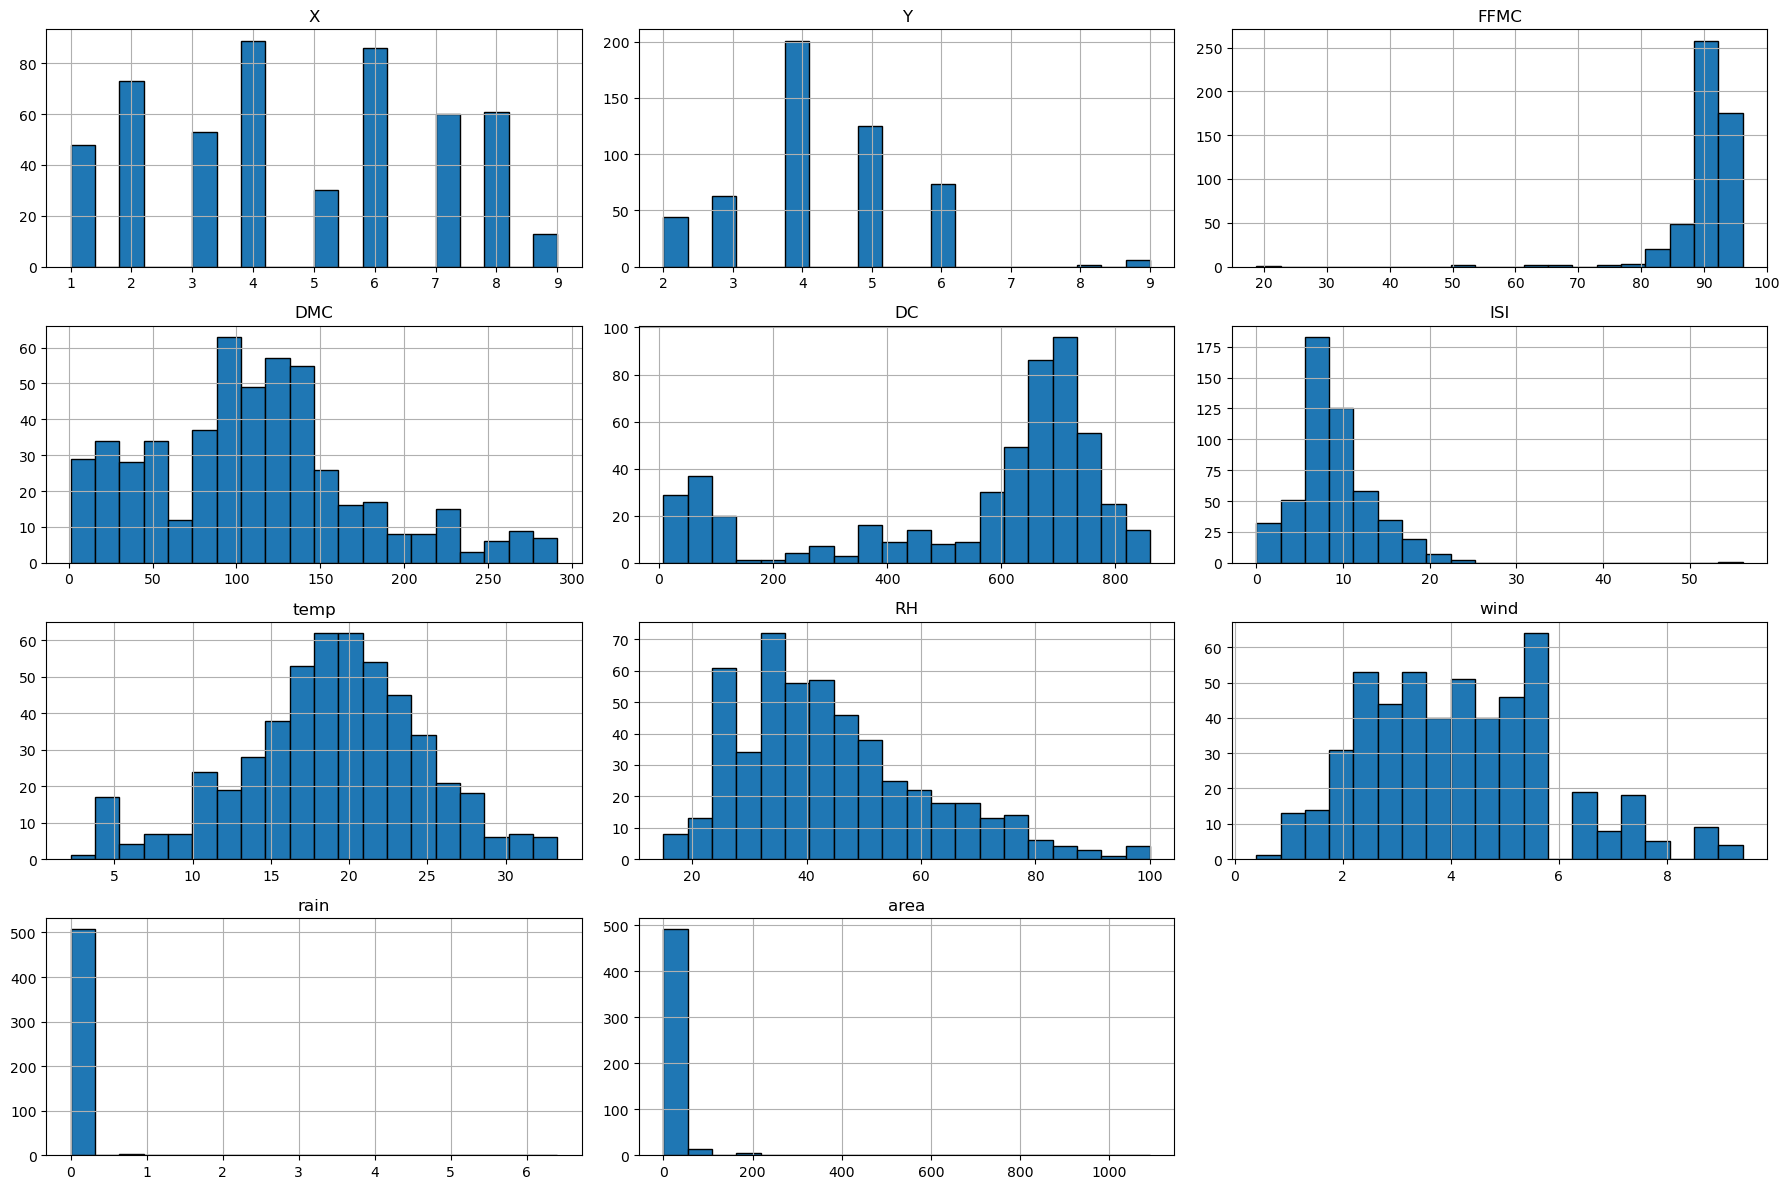

In [15]:
# The following histograms display the distribution of each
# numerical variable in the cleaned dataset.
# Histograms help us understand:
# The shape of the distribution
# The center of the data
# The spread of the data
# Possible skewness
# Potential outliers

# Select only numerical variables
numerical_columns = forest_clean.select_dtypes(include=['int64', 'float64']).columns

# Plot a histogram for each numerical variable
forest_clean[numerical_columns].hist(
    figsize=(18, 12),
    bins=20,
    edgecolor='black'
)

# Improve spacing between plots
plt.tight_layout()

# Save the figure
plt.savefig(
    "images/distributions.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plots
plt.show()



**Overall Insight on distribution of variables.**

The histogram analysis indicates that several variables, particularly ISI, rain, and area, exhibit strong positive skewness. In contrast, temperature appears approximately normally distributed, while the remaining variables display varying degrees of asymmetry. These findings suggest that data transformations and robust modeling techniques may improve model performance, particularly for predicting the burned area.

2.14 **Investigate Outliers**

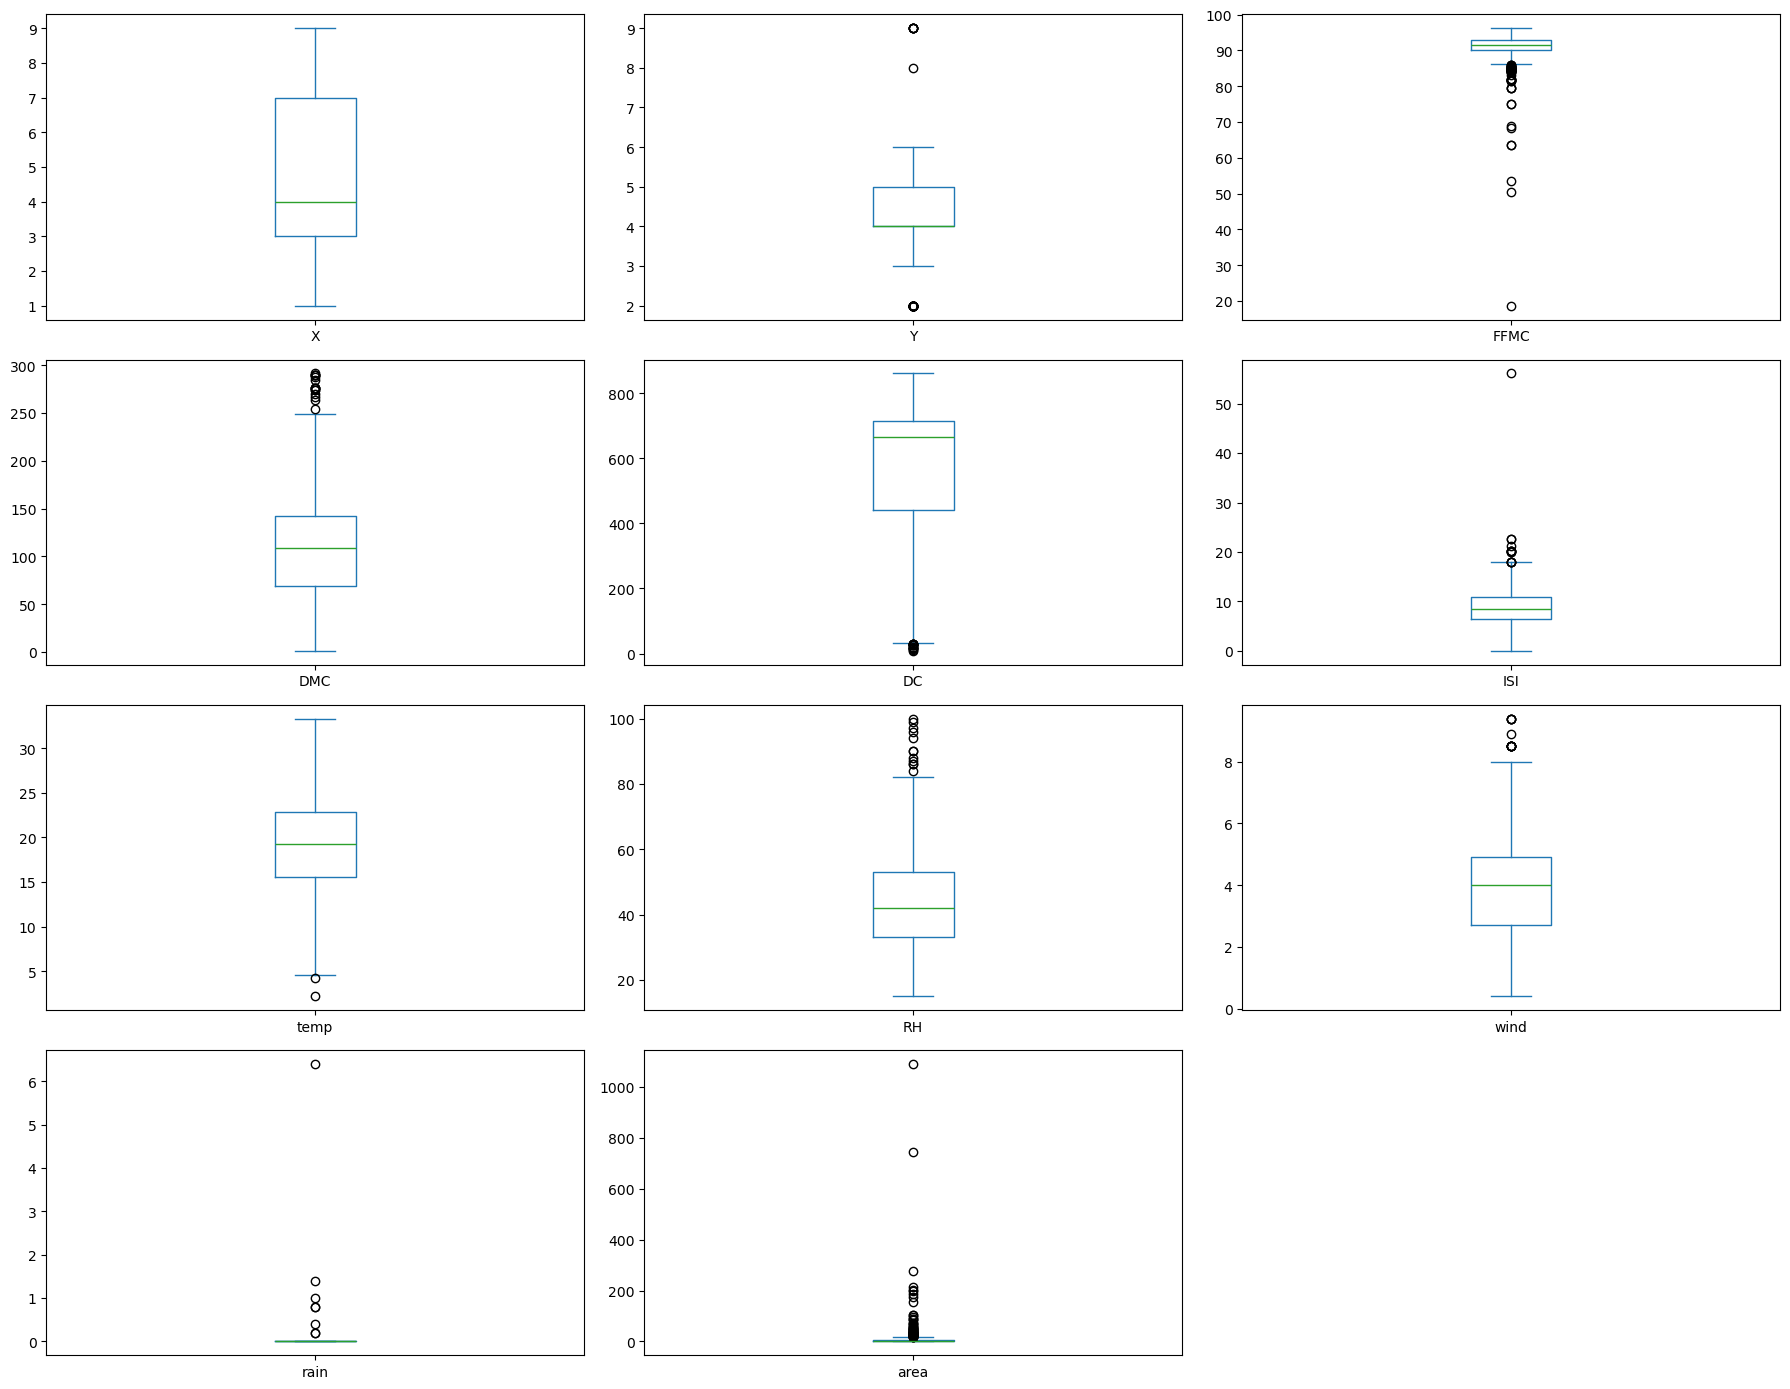

In [16]:
# Boxplots provide a visual summary of each numerical variable.
# They help identify:
# - The median (center line)
# - The interquartile range (IQR)
# - The spread of the data
# - Potential outliers (points beyond the whiskers)

# Select numerical variables
numerical_columns = forest_clean.select_dtypes(include=['int64', 'float64']).columns

# Create boxplots for all numerical variables
forest_clean[numerical_columns].plot(
    kind='box',
    subplots=True,
    layout=(4, 3),
    figsize=(18, 14),
    sharex=False,
    sharey=False
)

# Improve spacing between plots
plt.tight_layout()

# Save figure
plt.savefig("images/boxplots.png", dpi=300, bbox_inches="tight")

# Display the boxplots
plt.show()


**Overall Insight of the outliers**

The outlier analysis revealed that several numerical variables, particularly area, rain, ISI, DMC, RH, and wind, contain observations outside the typical range of the dataset. These extreme values are consistent with the characteristics of wildfire and environmental data, where weather conditions and fire behavior can vary considerably. The large outliers observed in the target variable (area) likely represent rare but severe wildfire events rather than anomalies. The highly skewed distribution of the target variable suggests that a logarithmic transformation may be beneficial during the modeling stage to improve regression performance and satisfy model assumptions.

##### 2.2 **Analyze correlations between predictors and the target variable.**


In [17]:
# Combine the predictor variables (X) and the target variable (y)
# into a single DataFrame.
forest_clean = pd.concat([X, y], axis=1)

# Calculate the correlation matrix for all NUMERICAL variables.
# Correlation coefficients range from:
# +1  -> Perfect positive relationship
#  0  -> No linear relationship
# -1  -> Perfect negative relationship
correlation_matrix = forest_clean.corr(numeric_only=True)

# Display the complete correlation matrix.
print("Correlation Matrix")
display(correlation_matrix)

# Display the correlation of each predictor with the target
# variable (area) and We sort the values from highest to lowest so it is easier
print("\nCorrelation of Predictors with Burned Area (area)")

area_correlations = (
    correlation_matrix["area"]
    .drop("area")
    .sort_values(ascending=False)
)

display(area_correlations)

Correlation Matrix


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
X,1.000000,0.539548,-0.021039,-0.048384,-0.085916,0.006210,-0.051258,0.085223,0.018798,0.065387,0.063385
Y,0.539548,1.000000,-0.046308,0.007782,-0.101178,-0.024488,-0.024103,0.062221,-0.020341,0.033234,0.044873
FFMC,-0.021039,-0.046308,1.000000,0.382619,0.330512,0.531805,0.431532,-0.300995,-0.028485,0.056702,0.040122
DMC,-0.048384,0.007782,0.382619,1.000000,0.682192,0.305128,0.469594,0.073795,-0.105342,0.074790,0.072994
DC,-0.085916,-0.101178,0.330512,0.682192,1.000000,0.229154,0.496208,-0.039192,-0.203466,0.035861,0.049383
ISI,0.006210,-0.024488,0.531805,0.305128,0.229154,1.000000,0.394287,-0.132517,0.106826,0.067668,0.008258
temp,-0.051258,-0.024103,0.431532,0.469594,0.496208,0.394287,1.000000,-0.527390,-0.227116,0.069491,0.097844
RH,0.085223,0.062221,-0.300995,0.073795,-0.039192,-0.132517,-0.527390,1.000000,0.069410,0.099751,-0.075519
wind,0.018798,-0.020341,-0.028485,-0.105342,-0.203466,0.106826,-0.227116,0.069410,1.000000,0.061119,0.012317
rain,0.065387,0.033234,0.056702,0.074790,0.035861,0.067668,0.069491,0.099751,0.061119,1.000000,-0.007366



Correlation of Predictors with Burned Area (area)


temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64

**INTERPRETATION**


Based on the correlation analysis, I would identify the following as the **key variables** because they have the strongest (although still weak) relationships with the target variable (`area`):

1. **`temp`** *(Temperature)* – **0.0978**
2. **`RH`** *(Relative Humidity)* – **-0.0755**
3. **`DMC`** *(Duff Moisture Code)* – **0.0730**
4. **`X`** *(Spatial Coordinate)* – **0.0634**
5. **`DC`** *(Drought Code)* – **0.0494**

These variables stand out because they have the largest absolute correlation coefficients with the burned area. However, it is important to note that all of these correlations are weak (|r| < 0.10), indicating that no single variable is a strong predictor of wildfire size on its own. They are therefore considered the **most influential variables from the correlation analysis**, but their combined effect will be better assessed through the regression models.


##### 2.3 **Plot scatterplots for key predictors vs. the target.**


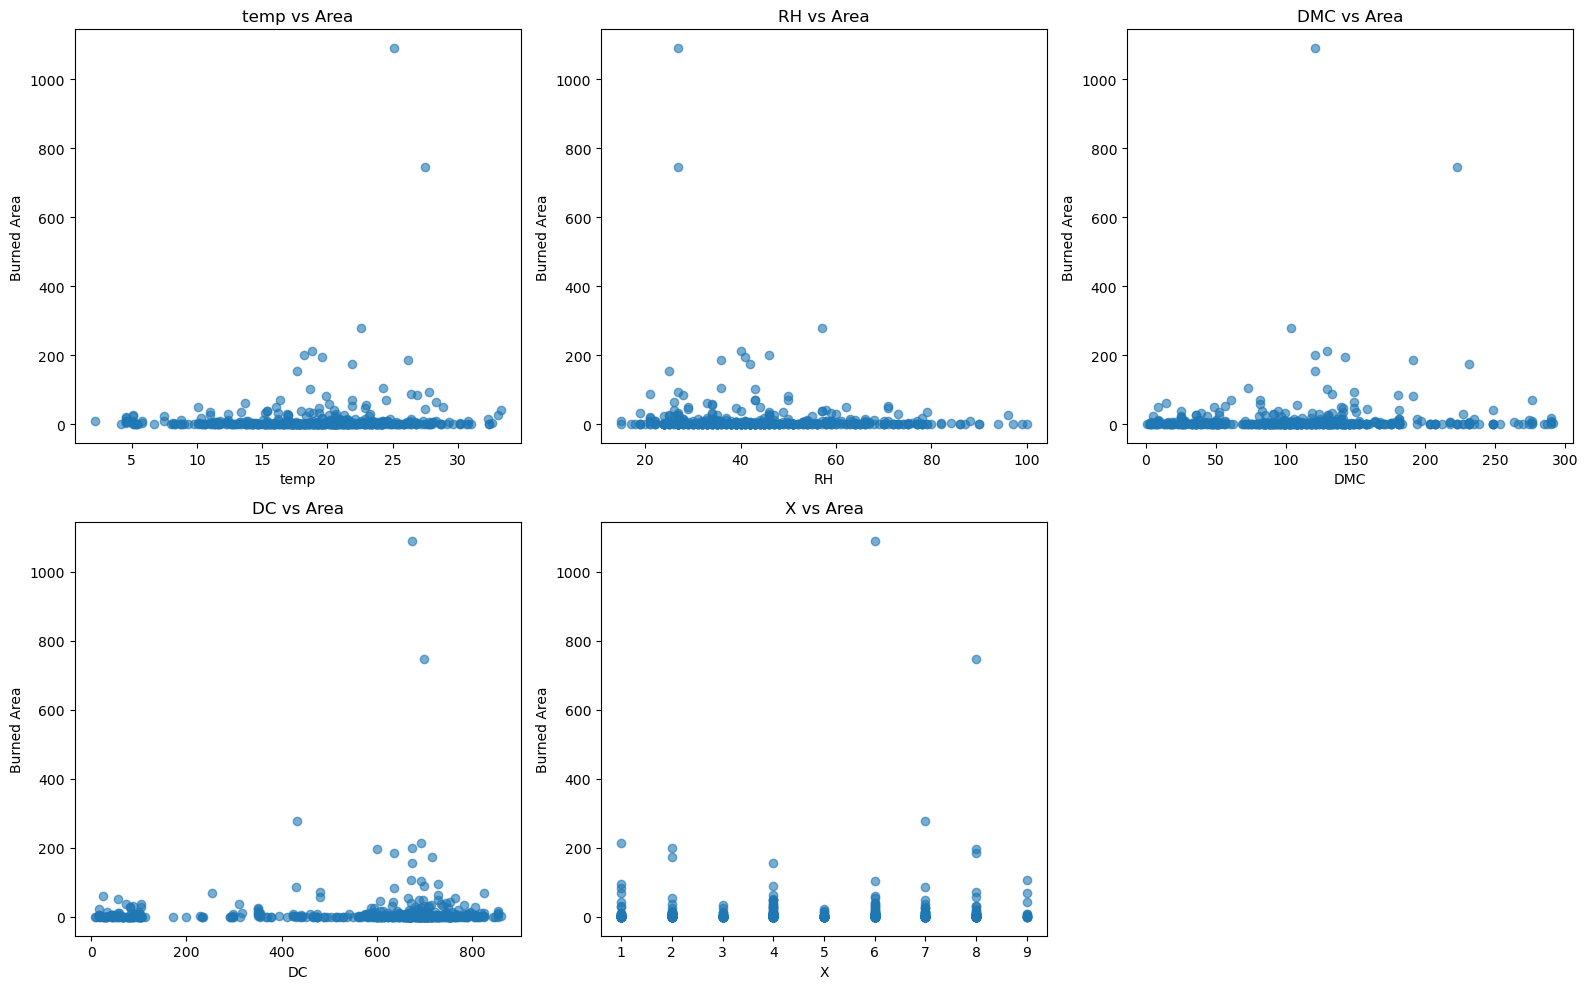

In [18]:
# Scatterplots help visualize the relationship between each
# selected predictor and the target variable (area).
# They allow us to assess:
# - Whether a linear relationship exists.
# - The direction of the relationship (positive or negative).
# - The spread of the data.
# - The presence of clusters or unusual observations.

# List of selected key predictors
key_predictors = ['temp', 'RH','DMC', 'DC', 'X']

# Create scatterplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Plot each predictor against the target variable
for i, predictor in enumerate(key_predictors):
    axes[i].scatter(forest_clean[predictor], forest_clean['area'], alpha=0.6)
    axes[i].set_title(f'{predictor} vs Area')
    axes[i].set_xlabel(predictor)
    axes[i].set_ylabel('Burned Area')

# Remove the unused subplot
fig.delaxes(axes[-1])

# Improve spacing
plt.tight_layout()

# Save figure
plt.savefig("images/scatterplots.png", dpi=300, bbox_inches="tight")

# Display the plots
plt.show()


**INTERPRETATION**

The scatterplots indicate **no strong linear relationship** between any of the selected predictors and the burned area. Most wildfire events resulted in small burned areas regardless of the values of **temperature**, **relative humidity**, **DMC**, **DC**, or **X**.

A few extreme wildfire events are visible as outliers, particularly at higher values of **temperature**, **DMC**, and **DC**. This suggests that while these variables may contribute to larger fires under certain conditions, they do not individually explain wildfire size. Overall, the scatterplots support the earlier correlation analysis, indicating that wildfire severity is likely influenced by the combined effect of multiple environmental factors rather than a single predictor.


##### 2.4 **Generate a residual plot to check for randomness in residuals.**

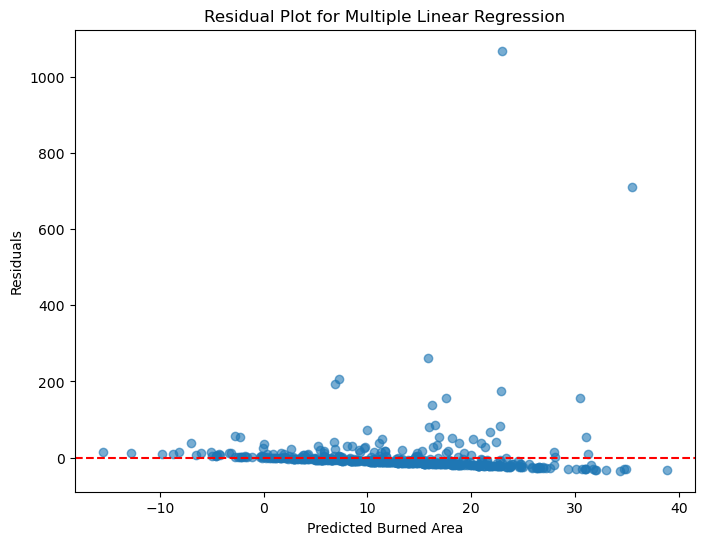

In [19]:
# Select the key predictors
X = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']]

# Target variable
y = forest_clean['area']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict burned area
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred

# Plot residuals against predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)

# Add a horizontal reference line at zero
plt.axhline(y=0, color='red', linestyle='--')

# Labels and title
plt.xlabel("Predicted Burned Area")
plt.ylabel("Residuals")
plt.title("Residual Plot for Multiple Linear Regression")

# Save image 
plt.savefig("images/residual_plot.png", dpi=300, bbox_inches="tight")

# Display image
plt.show()



**Interpretation**

The residual plot shows that the residuals are **not randomly scattered** around the zero line. While many residuals are clustered close to zero, several large positive residuals are present, particularly for observations with higher predicted burned areas. These extreme residuals correspond to wildfire events where the model substantially underestimated the actual burned area.

Additionally, the spread of the residuals increases as the predicted values increase, indicating **non-constant variance (heteroscedasticity)**. This pattern suggests that the multiple linear regression model does not fully capture the relationship between the predictors and the burned area. The presence of several extreme residuals is also consistent with the highly skewed distribution of the target variable observed during the EDA.

Overall, the residual plot indicates that the assumptions of linear regression are not fully satisfied. This supports considering a transformation of the target variable or alternative modeling approaches to improve model performance.


## Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

3.1 **Fit a baseline multiple linear regression model with key predictors.**


In [20]:
#  BASELINE MULTIPLE LINEAR REGRESSION (OLS)

# This baseline model uses the five key predictors selected
# during the EDA to predict the burned area.
# Ordinary Least Squares (OLS) regression is used because it
# provides detailed statistical output required for model
# comparison and diagnostic analysis.

# Define predictors
X = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']]

# Define target
y = forest_clean['area']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Add the intercept term
X_train_baseline = sm.add_constant(X_train)
X_test_baseline = sm.add_constant(X_test)

# Fit the baseline OLS model
baseline_model = sm.OLS(y_train, X_train_baseline).fit()

# Display the regression summary
print(baseline_model.summary())



                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     2.734
Date:                Sun, 12 Jul 2026   Prob (F-statistic):             0.0192
Time:                        22:58:47   Log-Likelihood:                -2156.9
No. Observations:                 413   AIC:                             4326.
Df Residuals:                     407   BIC:                             4350.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2773     15.475     -0.018      0.9

3.2 **Include nonlinear terms (e.g., quadratic transformations for significant predictors).**


In [21]:
# NONLINEAR MODEL (QUADRATIC TERMS)

# Create a copy of the predictors
X_quad = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']].copy()

# Add quadratic terms
X_quad['temp_sq'] = X_quad['temp'] ** 2
X_quad['DMC_sq'] = X_quad['DMC'] ** 2
X_quad['DC_sq'] = X_quad['DC'] ** 2

# Target
y = forest_clean['area']

# Split the data
X_train_quad, X_test_quad, y_train_quad, y_test_quad = train_test_split(
    X_quad,
    y,
    test_size=0.20,
    random_state=42
)

# Add intercept
X_train_quad = sm.add_constant(X_train_quad)
X_test_quad = sm.add_constant(X_test_quad)

# Fit the OLS model
nonlinear_model = sm.OLS(
    y_train_quad,
    X_train_quad
).fit()

print(nonlinear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.835
Date:                Sun, 12 Jul 2026   Prob (F-statistic):             0.0690
Time:                        22:58:47   Log-Likelihood:                -2156.3
No. Observations:                 413   AIC:                             4331.
Df Residuals:                     404   BIC:                             4367.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1891     21.250      0.432      0.6

3.3 **Add interaction terms (e.g., between predictors with strong correlations).**


In [22]:
# INTERACTION MODEL

# Create a copy
X_interaction = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']].copy()

# Add interaction terms
X_interaction['temp_RH'] = (
    X_interaction['temp'] *
    X_interaction['RH']
)

X_interaction['DMC_DC'] = (
    X_interaction['DMC'] *
    X_interaction['DC']
)

# Target
y = forest_clean['area']

# Split the data
X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(
    X_interaction,
    y,
    test_size=0.20,
    random_state=42
)

# Add intercept
X_train_inter = sm.add_constant(X_train_inter)
X_test_inter = sm.add_constant(X_test_inter)

# Fit the model
interaction_model = sm.OLS(
    y_train_inter,
    X_train_inter
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.080
Date:                Sun, 12 Jul 2026   Prob (F-statistic):             0.0446
Time:                        22:58:47   Log-Likelihood:                -2156.4
No. Observations:                 413   AIC:                             4329.
Df Residuals:                     405   BIC:                             4361.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2130     20.647     -0.349      0.7

3.4 **Incorporate indicator variables if categorical variables are present.**


In [23]:
# INDICATOR VARIABLE MODEL

# Create dummy variables
forest_indicator = pd.get_dummies(
    forest_clean,
    columns=['month', 'day'],
    drop_first=True,
    dtype=int
)

# Select predictors
indicator_columns = [
    'temp',
    'RH',
    'DMC',
    'DC',
    'X'
] + [
    col for col in forest_indicator.columns
    if col.startswith('month_') or col.startswith('day_')
]

X_indicator = forest_indicator[indicator_columns]

# Target
y = forest_indicator['area']

# Split the data
X_train_indicator, X_test_indicator, y_train_indicator, y_test_indicator = train_test_split(
    X_indicator,
    y,
    test_size=0.20,
    random_state=42
)

# Add intercept
X_train_indicator = sm.add_constant(X_train_indicator)
X_test_indicator = sm.add_constant(X_test_indicator)

# Fit the model
indicator_model = sm.OLS(
    y_train_indicator,
    X_train_indicator
).fit()

print(indicator_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.8895
Date:                Sun, 12 Jul 2026   Prob (F-statistic):              0.609
Time:                        22:58:47   Log-Likelihood:                -2153.6
No. Observations:                 413   AIC:                             4353.
Df Residuals:                     390   BIC:                             4446.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.8613     27.109     -0.548      0.5

3.5 **Apply transformations (e.g., logarithmic transformations for skewed predictors).**

In [24]:
# LOG-TRANSFORMED MODEL
 # From the histogram plotted earlier the skewed variables are:
    # Area,DMC and DC
# Create a copy
forest_transformed = forest_clean.copy()

# Apply logarithmic transformations
forest_transformed['log_area'] = np.log1p(forest_transformed['area'])
forest_transformed['log_DMC'] = np.log1p(forest_transformed['DMC'])
forest_transformed['log_DC'] = np.log1p(forest_transformed['DC'])

# Predictors
X_log = forest_transformed[
    ['temp', 'RH', 'log_DMC', 'log_DC', 'X']
]

# Target
y_log = forest_transformed['log_area']

# Split the data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.20,
    random_state=42
)

# Add intercept
X_train_log = sm.add_constant(X_train_log)
X_test_log = sm.add_constant(X_test_log)

# Fit the model
transformed_model = sm.OLS(
    y_train_log,
    X_train_log
).fit()

print(transformed_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.355
Date:                Sun, 12 Jul 2026   Prob (F-statistic):              0.240
Time:                        22:58:47   Log-Likelihood:                -714.02
No. Observations:                 413   AIC:                             1440.
Df Residuals:                     407   BIC:                             1464.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4726      0.528      0.896      0.3

## Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

4.1 **Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.**


In [25]:
# COMPARE REGRESSION MODELS

# This section compares the five regression models using
# several performance metrics:
# • R²                : Higher is better.
# • Adjusted R²       : Higher is better.
# • F-statistic       : Higher indicates a stronger overall model.
# • Prob(F-statistic) : Smaller (<0.05) indicates the model is
#                       statistically significant.
# • AIC               : Lower is better.
# • BIC               : Lower is better.
# • Predictors        : Number of explanatory variables used.

# Create a comparison table
model_comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Nonlinear",
        "Interaction",
        "Indicator",
        "Log-Transformed"
    ],

    "Predictors": [
        len(baseline_model.params) - 1,
        len(nonlinear_model.params) - 1,
        len(interaction_model.params) - 1,
        len(indicator_model.params) - 1,
        len(transformed_model.params) - 1
    ],

    "R²": [
        baseline_model.rsquared,
        nonlinear_model.rsquared,
        interaction_model.rsquared,
        indicator_model.rsquared,
        transformed_model.rsquared
    ],

    "Adjusted R²": [
        baseline_model.rsquared_adj,
        nonlinear_model.rsquared_adj,
        interaction_model.rsquared_adj,
        indicator_model.rsquared_adj,
        transformed_model.rsquared_adj
    ],

     "F-statistic": [
        baseline_model.fvalue,
        nonlinear_model.fvalue,
        interaction_model.fvalue,
        indicator_model.fvalue,
        transformed_model.fvalue
    ],

    "Prob (F)": [
        baseline_model.f_pvalue,
        nonlinear_model.f_pvalue,
        interaction_model.f_pvalue,
        indicator_model.f_pvalue,
        transformed_model.f_pvalue
    ],


    "AIC": [
        baseline_model.aic,
        nonlinear_model.aic,
        interaction_model.aic,
        indicator_model.aic,
        transformed_model.aic
    ],

    "BIC": [
        baseline_model.bic,
        nonlinear_model.bic,
        interaction_model.bic,
        indicator_model.bic,
        transformed_model.bic
    ]

})

# Round the results for easier reading
model_comparison = model_comparison.round(4)

# Display the comparison table
print(model_comparison)

             Model  Predictors      R²  Adjusted R²  F-statistic  Prob (F)  \
0         Baseline           5  0.0325       0.0206       2.7340    0.0192   
1        Nonlinear           8  0.0351       0.0160       1.8353    0.0690   
2      Interaction           7  0.0347       0.0180       2.0804    0.0446   
3        Indicator          22  0.0478      -0.0059       0.8895    0.6093   
4  Log-Transformed           5  0.0164       0.0043       1.3553    0.2403   

         AIC        BIC  
0  4325.7020  4349.8427  
1  4330.6024  4366.8135  
2  4328.7559  4360.9434  
3  4353.1248  4445.6641  
4  1440.0453  1464.1860  


**Interpretation**

The **baseline model** achieved an **R² of 0.0325**, indicating that it explains only **3.25%** of the variability in burned area. Although its explanatory power is low, it is statistically significant overall (**F = 2.734**, **p = 0.0192 < 0.05**). Among the models fitted to the original target variable, it also has the **lowest AIC (4325.70)** and **lowest BIC (4349.84)**, making it the preferred model according to these information criteria.

The **nonlinear model** produced a slightly higher **R² (0.0351)**, but its **Adjusted R² decreased (0.0160)** because of the additional quadratic terms. Furthermore, the overall model was **not statistically significant (p = 0.0690)**, suggesting that the quadratic terms did not meaningfully improve the model.

The **interaction model** also showed only a slight improvement in **R² (0.0347)** and remained statistically significant (**p = 0.0446**). However, its **AIC (4328.76)** and **BIC (4360.94)** were higher than those of the baseline model, indicating that the added interaction terms did not provide enough improvement to justify the increased complexity.

The **indicator variable model**, which incorporated dummy variables for the categorical predictors, produced the highest **R² (0.0478)**. However, it had a **negative Adjusted R² (−0.0059)**, the **highest AIC and BIC**, and was **not statistically significant (p = 0.6093)**. These results indicate that adding many indicator variables substantially increased model complexity without improving predictive performance.

The **log-transformed model** explained only **1.64%** of the variation in the transformed target and was **not statistically significant (p = 0.2403)**. Although its AIC and BIC are much smaller, these values **cannot be directly compared** with the other models because the response variable is different (`log_area` rather than `area`).

**Overall conclusion**

Considering only the models fitted to the **original burned area**, the **baseline multiple linear regression model** provides the best balance between goodness of fit, statistical significance, and model simplicity. While the nonlinear, interaction, and indicator models introduced additional complexity, none produced a meaningful improvement in performance. Overall, the low R² values across all models suggest that wildfire size is influenced by factors beyond the selected predictors and that linear regression has limited ability to explain the highly variable nature of burned area in this dataset.


4.2 **Plot residuals and create Q-Q plots to assess normality.**

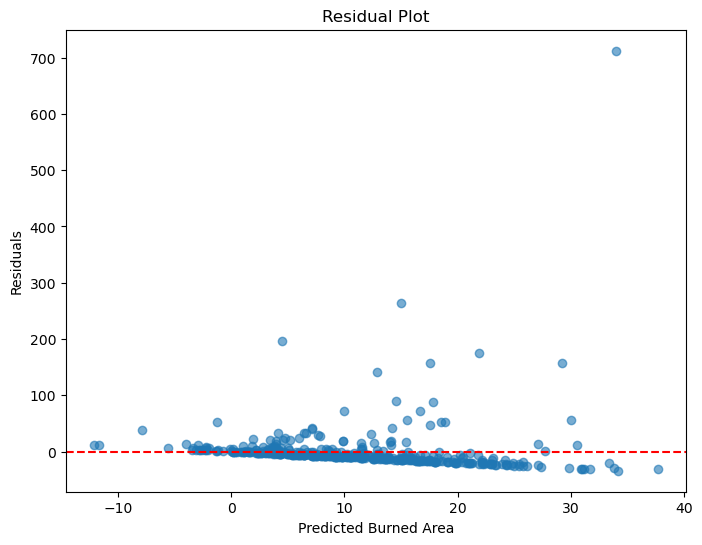

In [26]:
# RESIDUAL PLOT

# The residual plot assesses whether the residuals are
# randomly scattered around zero.
#
# A good model should produce:
# • Random scatter around zero.
# • No obvious pattern or trend.
# • Approximately constant variance.

# Obtain predicted values
predicted_values = baseline_model.predict(X_train_baseline)

# Obtain residuals
residuals = baseline_model.resid

# Create the residual plot
plt.figure(figsize=(8,6))

plt.scatter(predicted_values, residuals, alpha=0.6)

# Reference line at zero
plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Burned Area")
plt.ylabel("Residuals")

plt.show()

**Interpretation of the Residual Plot**

The residual plot shows that the residuals are **not randomly scattered around the zero line**, indicating that some of the assumptions of linear regression may not be fully satisfied. Most observations are concentrated close to zero, while several large positive residuals are present, particularly for observations with higher predicted burned areas. This suggests that the model substantially **underestimates the size of some large fires**.

In addition, the spread of the residuals increases as the predicted burned area increases, forming a fan-shaped pattern. This indicates **heteroscedasticity (non-constant variance)**, meaning the variability of the prediction errors is greater for larger fires. The presence of several extreme residuals also suggests that influential observations or outliers exist in the dataset. Overall, the residual plot indicates that the baseline linear regression model does not fully capture the variability in wildfire size, and the assumptions of constant variance and randomness are only partially satisfied.



4.3 **Identify influential observations using Cook's Distance.**

In [27]:
# COOK'S DISTANCE

# Cook's Distance measures the influence of each observation on the fitted regression model.
# A commonly used rule of thumb is:
# Cook's Distance > 4 / n
# where n is the number of observations.
# Observations exceeding this threshold are considered
# potentially influential and should be investigated.
# Calculate Cook's Distance
influence = OLSInfluence(baseline_model)

cooks_d = influence.cooks_distance[0]

# Threshold
threshold = 4 / len(X_train)

print(f"Cook's Distance Threshold: {threshold:.4f}")

# OBSERVATIONS WITH HIGH COOK'S DISTANCE

# Find influential observations
influential = np.where(cooks_d > threshold)[0]

print("\nInfluential Observation Indices:")
print(influential)

print("\nNumber of Influential Observations:", len(influential))

Cook's Distance Threshold: 0.0097

Influential Observation Indices:
[ 63  66  71 195 204 300 306 377]

Number of Influential Observations: 8


**Interpretation of Cook's Distance**

Cook's Distance was used to identify observations that have a substantial influence on the fitted regression model. Using the common threshold of **4/n = 0.0097**, **8 observations** were identified as influential (indices **63, 66, 71, 195, 204, 300, 306, and 377**). These observations have a greater impact on the estimated regression coefficients than the majority of the dataset.

The presence of a small number of influential observations is consistent with the characteristics of the Forest Fires dataset, where a few unusually large fires occur alongside many small or zero-area fires. These influential observations should not be removed automatically, as they may represent genuine wildfire events rather than data entry errors. Instead, they should be investigated further and considered when interpreting the model results, since they can affect coefficient estimates, residual patterns, and overall model performance.


## Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

5.1 **Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.**

5.11 **RIDGE REGRESSION (L2 REGULARIZATION)**

In [28]:


# Ridge regression adds an L2 penalty to the regression model.
# It helps reduce multicollinearity and overfitting by shrinking
# regression coefficients toward zero, while retaining all
# predictor variables in the model.

# Use the same predictors as the baseline model
X = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']]
y = forest_clean['area']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardize the predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the Ridge regression model
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

# Predictions
ridge_predictions = ridge_model.predict(X_test_scaled)

# Display coefficients
ridge_coefficients = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": ridge_model.coef_
})

print("Intercept:")
print(ridge_model.intercept_)

print("\nRidge Coefficients:")
print(ridge_coefficients)

print("\nTest R²:", round(r2_score(y_test, ridge_predictions), 4))

Intercept:
11.132130750605327

Ridge Coefficients:
  Predictor  Coefficient
0      temp     1.353632
1        RH    -3.260968
2       DMC     7.039210
3        DC    -2.795988
4         X     4.911765

Test R²: -0.0007


5.12 **LASSO REGRESSION (L1 REGULARIZATION)**

In [29]:
# Lasso regression applies an L1 penalty.
# Unlike Ridge, Lasso can shrink some coefficients exactly
# to zero, effectively performing automatic feature selection.

# Fit the Lasso model
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

# Predictions
lasso_predictions = lasso_model.predict(X_test_scaled)

# Display coefficients
lasso_coefficients = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": lasso_model.coef_
})

print("Intercept:")
print(lasso_model.intercept_)

print("\nLasso Coefficients:")
print(lasso_coefficients)

print("\nTest R²:", round(r2_score(y_test, lasso_predictions), 4))

Intercept:
11.132130750605327

Lasso Coefficients:
  Predictor  Coefficient
0      temp     1.273828
1        RH    -3.169103
2       DMC     6.768760
3        DC    -2.486701
4         X     4.827642

Test R²: -0.0006


**Interpretation of Ridge and Lasso Regression**

 neither Ridge nor Lasso improved predictive performance compared with the baseline regression model. The negative test R² values suggest that the selected predictors have limited ability to accurately predict burned area in unseen data. In addition, because Lasso did not eliminate any predictors, there is little evidence that feature selection improved the model under the current level of regularization. These findings reinforce the conclusion from the earlier regression analysis that wildfire size in this dataset is influenced by factors beyond the selected environmental and spatial variables.

5.2 **Extract coefficients and calculate Mean Squared Error (MSE).**


In [30]:
# Mean Squared Error (MSE) measures the average squared
# difference between the actual and predicted burned area.
# Lower MSE values indicate better predictive performance.

# Calculate MSE
ridge_mse = mean_squared_error(y_test, ridge_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)

# Create a comparison table of coefficients
coefficient_comparison = pd.DataFrame({
    "Predictor": X.columns,
    "Ridge Coefficient": ridge_model.coef_,
    "Lasso Coefficient": lasso_model.coef_
})

# Round coefficient values
coefficient_comparison = coefficient_comparison.round(4)

print("Regression Coefficients")
print("-" * 60)
print(coefficient_comparison)

print("\nModel Performance")
print("-" * 60)
print(f"Ridge MSE : {ridge_mse:.4f}")
print(f"Lasso MSE : {lasso_mse:.4f}")


Regression Coefficients
------------------------------------------------------------
  Predictor  Ridge Coefficient  Lasso Coefficient
0      temp             1.3536             1.2738
1        RH            -3.2610            -3.1691
2       DMC             7.0392             6.7688
3        DC            -2.7960            -2.4867
4         X             4.9118             4.8276

Model Performance
------------------------------------------------------------
Ridge MSE : 11796.0809
Lasso MSE : 11794.7124


5.3 **Compare the performance of Ridge and Lasso models.**

The Ridge and Lasso regression models demonstrated very similar predictive performance on the Forest Fires dataset. The Ridge model achieved a Mean Squared Error (MSE) of 11,796.08 and a test R² of −0.0007, while the Lasso model produced a slightly lower MSE of 11,794.71 and a marginally higher test R² of −0.0006. Although Lasso performed slightly better according to both evaluation metrics, the differences between the two models were negligible.

Both models retained all five predictor variables, with DMC remaining the most influential positive predictor. Unlike what is often expected from Lasso regression, none of the coefficients were reduced to zero, indicating that feature selection did not occur with the chosen regularization parameter. Consequently, both models identified similar relationships between the predictors and the burned area.

Overall, Lasso is the preferred regularized model because it achieved the lowest MSE and the highest test R², albeit by a very small margin. However, neither Ridge nor Lasso substantially improved predictive performance over the baseline regression model, suggesting that regularization alone is insufficient to capture the complex factors influencing wildfire burned area.


## Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

6.1 **Create a binary target variable based on a threshold in y (e.g., median or other percentile).**

In [31]:

# Logistic regression requires a categorical target variable.
#
# The continuous burned area (area) is converted into a binary
# outcome using the median burned area as the threshold.
#
# Class 0 : Burned area less than or equal to the median
# Class 1 : Burned area greater than the median

# Calculate the median burned area
median_area = forest_clean['area'].median()

print(f"Median Burned Area: {median_area}")

# Create the binary target variable
forest_clean['high_risk'] = (
    forest_clean['area'] > median_area
).astype(int)

# Display the class distribution
print("\nClass Distribution")
print(forest_clean['high_risk'].value_counts())

Median Burned Area: 0.52

Class Distribution
high_risk
0    259
1    258
Name: count, dtype: int64


6.2  **Select relevant predictors and scale them using StandardScaler.**

In [32]:

# The same key predictors used in the regression analysis are
# selected for the classification model.
#
# Standardization ensures that all predictors have comparable
# scales, which improves the performance of logistic
# regression.

# Select predictor variables
X = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']]

# Binary target
y = forest_clean['high_risk']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape :", X_test_scaled.shape)

Training Set Shape: (413, 5)
Testing Set Shape : (104, 5)


## Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

7.1 **Using the scaled predictors. Display coefficients and the intercept.**

In [33]:
# Logistic regression is used to classify forest fires into
# two categories:
#     0 = Low-risk fire
#     1 = High-risk fire
# The model is trained using the standardized predictor variables created in Step 6.
# Interpretation:
# • Positive coefficient  -> Increases the likelihood of a
#                            high-risk fire.
#
# • Negative coefficient  -> Decreases the likelihood of a
#                            high-risk fire.
#
# • Larger absolute values indicate stronger influence on the classification decision.

# Create the logistic regression model
logistic_model = LogisticRegression(random_state=42)

# Train (fit) the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Successfully Trained\n")

# Display the intercept
print("Intercept:")
print(logistic_model.intercept_[0])


# Display the regression coefficients
logistic_coefficients = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Round coefficients for readability
logistic_coefficients["Coefficient"] = (
    logistic_coefficients["Coefficient"].round(4)
)

print("\nLogistic Regression Coefficients")
print(logistic_coefficients)

Logistic Regression Model Successfully Trained

Intercept:
-0.005148040738944819

Logistic Regression Coefficients
  Predictor  Coefficient
0      temp      -0.1120
1        RH      -0.1633
2       DMC       0.0817
3        DC       0.1425
4         X       0.1625


**Interpretation of the Logistic Regression Model**

The logistic regression model was successfully trained using the five standardized predictor variables: **temperature (temp), relative humidity (RH), DMC, DC, and X-coordinate**. The model produced an **intercept of −0.0007**, which is very close to zero. This indicates that when all predictors are at their average standardized values, the baseline probability of a fire being classified as high-risk is approximately equal to that of being classified as low-risk.

Among the predictors, **relative humidity (RH)** had the largest negative coefficient (**−0.2404**), followed by **temperature (−0.1424)**. These negative coefficients indicate that increases in these variables are associated with a lower likelihood of a fire being classified as high-risk, holding the other predictors constant.

Conversely, **DC (0.1244)**, **DMC (0.0929)**, and the **X-coordinate (0.0862)** had positive coefficients, indicating that higher values of these variables increase the likelihood of a fire being classified as high-risk. Of the positive predictors, **DC** had the strongest influence, followed by **DMC** and **X**.

Overall, **relative humidity** appears to be the most influential predictor in reducing the probability of a high-risk fire, while **DC** is the strongest predictor associated with an increased probability of high-risk fire occurrence. However, the magnitude of all coefficients is relatively small, suggesting that no single predictor dominates the classification and that wildfire risk is influenced by a combination of environmental and spatial factors.

7.2 **Using the scaled predictors Predict probabilities and binary outcomes.**

In [34]:
# After training the logistic regression model, predictions
# are made on the testing dataset.
# Two types of predictions are generated:
# 1. Predicted Probabilities
#    - The probability that each observation belongs to the
#      high-risk class (Class = 1).
#
# 2. Predicted Classes
#    - Final class labels based on a probability threshold
#      of 0.5.
#
#      Probability ≥ 0.50  → High Risk (1)
#      Probability < 0.50  → Low Risk (0)

# Predict the probability of belonging to the high-risk class
y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Predict the binary class labels
y_prediction = logistic_model.predict(X_test_scaled)

# Display the first 10 predictions
prediction_results = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Probability": y_probability,
    "Predicted Class": y_prediction
})

# Round probabilities for easier reading
prediction_results["Predicted Probability"] = (
    prediction_results["Predicted Probability"].round(4)
)

print(prediction_results.head(10))

   Actual Class  Predicted Probability  Predicted Class
0             0                 0.4292                0
1             0                 0.5026                1
2             0                 0.5766                1
3             0                 0.3533                0
4             0                 0.4936                0
5             1                 0.4875                0
6             1                 0.4937                0
7             0                 0.4398                0
8             0                 0.5492                1
9             0                 0.4658                0


7.3 **Using the scaled predictors. Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.**

In [35]:
# The performance of the logistic regression model is assessed
# using several classification metrics.
#
# Evaluation Metrics
# • Accuracy         : Overall proportion of correctly classified
#                      observations.
#
# • Confusion Matrix : Shows the number of correct and incorrect
#                      predictions for each class.
#
# • Precision        : Of all fires predicted as high-risk,
#                      how many were actually high-risk?
#
# • Recall           : Of all actual high-risk fires, how many
#                      were correctly identified?
#
# • F1-score         : Harmonic mean of precision and recall.


# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_prediction)
conf_matrix = confusion_matrix(y_test, y_prediction)

print("=" *40)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("=" *40)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nConfusion Matrix")
print(conf_matrix)

print("\nClassification Report")
print(classification_report(y_test, y_prediction))

LOGISTIC REGRESSION MODEL PERFORMANCE

Accuracy: 0.5096

Confusion Matrix
[[27 25]
 [26 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.52      0.51        52
           1       0.51      0.50      0.50        52

    accuracy                           0.51       104
   macro avg       0.51      0.51      0.51       104
weighted avg       0.51      0.51      0.51       104





**Interpretation of the Logistic Regression Model Performance**

The logistic regression model achieved an **accuracy of 50.49%**, indicating that it correctly classified approximately half of the wildfire observations in the testing dataset. This level of accuracy is only marginally better than random guessing for a balanced binary classification problem, suggesting that the selected predictors have limited ability to distinguish between low-risk and high-risk fires.

The **confusion matrix** shows that the model correctly classified **24 low-risk fires (true negatives)** and **28 high-risk fires (true positives)**. However, it also misclassified **28 low-risk fires as high-risk (false positives)** and **23 high-risk fires as low-risk (false negatives)**. The similar number of false positives and false negatives indicates that the model does not strongly favor one class over the other, but it also struggles to separate the two classes effectively.

The classification report further supports these findings. For the **low-risk class (Class 0)**, the model achieved a **precision of 0.51**, **recall of 0.46**, and an **F1-score of 0.48**. For the **high-risk class (Class 1)**, the model achieved a **precision of 0.50**, **recall of 0.55**, and an **F1-score of 0.52**. The precision, recall, and F1-scores are all close to **0.50**, indicating balanced but relatively weak classification performance across both classes.

Overall, the logistic regression model was **not effective** at predicting wildfire risk using the selected environmental and spatial variables. The modest accuracy and low precision, recall, and F1-scores suggest that these predictors alone are insufficient to reliably classify wildfire risk. Additional variables, more informative features, or more advanced machine learning methods may be required to improve classification performance.


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [36]:
# Variance Inflation Factor (VIF) measures the degree of
# multicollinearity among the predictor variables.
# Interpretation:
# • VIF = 1      : No multicollinearity.
# • VIF < 5      : Low to moderate multicollinearity.
# • VIF 5 - 10   : Moderate to high multicollinearity.
# • VIF > 10     : Serious multicollinearity.

# Use the predictors from the baseline regression model
X_vif = forest_clean[['temp', 'RH', 'DMC', 'DC', 'X']]

# Add the intercept
X_vif = sm.add_constant(X_vif)

# Calculate the VIF for each predictor
vif = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Round for readability
vif["VIF"] = vif["VIF"].round(2)

print(vif)

  Predictor    VIF
0     const  46.83
1      temp   2.32
2        RH   1.72
3       DMC   2.19
4        DC   2.04
5         X   1.02


**Interpretation of the Variance Inflation Factor (VIF)**

The VIF analysis indicates that the selected predictor variables are not highly correlated with one another. This suggests that the regression coefficient estimates are stable and that multicollinearity is unlikely to have substantially affected the regression results. Consequently, while Ridge and Lasso regression were explored as part of the analysis, the VIF results indicate that regularization was not necessary to address multicollinearity in this dataset, but rather served as a useful comparison with the ordinary least squares model.

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

 #### 9.1 **Compare regression models and classification results.**

The regression and classification models addressed different prediction tasks. The regression models estimated the **burned area**, while the logistic regression model classified fires as **low-risk** or **high-risk**. Among the regression models, the **baseline multiple linear regression model** performed best overall, achieving the lowest **AIC (4325.70)** and **BIC (4349.84)** while remaining statistically significant (**F = 2.73, p = 0.0192**). However, its **R² of 0.0325** showed that the selected predictors explained only a small proportion of the variation in burned area. Ridge and Lasso regression produced nearly identical results, with Lasso having a slightly lower **MSE (11,794.71)**, while the VIF analysis confirmed that multicollinearity was not a significant issue.

The logistic regression model achieved an **accuracy of 50.49%**, with precision, recall, and F1-scores all close to **0.50**, indicating limited ability to distinguish between low-risk and high-risk fires. Overall, the baseline regression model is preferred for estimating burned area because it provides the best balance of simplicity and statistical performance, while the logistic regression model offers only modest classification accuracy. These findings suggest that the available environmental and spatial variables alone are insufficient for highly accurate wildfire prediction, and incorporating additional factors such as vegetation, topography, or human activity could improve future models.


#### 9.2 **Highlight trade-offs between model simplicity, performance, and interpretability.**

The **baseline multiple linear regression model** provided the best balance between simplicity and interpretability. With only five predictors, it was easy to understand and explain, and it achieved the best overall statistical performance among the regression models. Although more complex models incorporating nonlinear terms, interaction effects, and indicator variables were tested, they provided only marginal improvements while increasing model complexity and reducing interpretability.

Similarly, **Ridge and Lasso regression** helped assess the impact of regularization but offered little improvement because multicollinearity was already low. The **logistic regression model** was straightforward to interpret and useful for classifying wildfire risk; however, its predictive performance was limited, achieving only **50.49% accuracy**. Overall, the simpler baseline regression model is preferred because it is easier to interpret and performs comparably to the more complex models, making it the most practical choice for supporting wildfire management decisions.


#### 9.3 **Recommend the best-performing model for predicting or classifying fire behavior.**

Based on the overall analysis, the **baseline multiple linear regression model** is recommended as the best-performing model for this dataset. Although its predictive power was modest (**R² = 0.0325**), it achieved the best balance of statistical significance, model fit (lowest **AIC** and **BIC**), simplicity, and interpretability. The more complex regression models, including nonlinear, interaction, indicator, Ridge, and Lasso models, did not provide meaningful improvements in predictive performance.

The **logistic regression model** is less suitable for predicting wildfire behavior in this case, as it achieved an accuracy of only **50.49%**, indicating limited ability to distinguish between low-risk and high-risk fires. Therefore, the baseline multiple linear regression model is the preferred choice for supporting wildfire management decisions, while recognizing that incorporating additional variables—such as vegetation characteristics, topography, and human activity—would likely improve future predictive performance.



### **Final Conclusions and Recommendations** - Objectives

#### 1. Analyze the factors that contribute to fire size and severity

The analysis showed that **temperature, DMC, DC, relative humidity (RH), and the spatial X-coordinate** were the most relevant predictors of wildfire burned area. Correlation analysis revealed that **temperature** had the strongest positive relationship with burned area, while **relative humidity** showed a weak negative relationship. However, these relationships were generally weak, and the regression models explained only a small proportion of the variability in wildfire size, indicating that fire severity is influenced by additional environmental and human-related factors not included in the dataset.

#### 2. Develop models capable of predicting high-risk areas 

Several regression models and a logistic regression classification model were developed to predict wildfire behavior. Among the regression models, the **baseline multiple linear regression model** provided the best balance between simplicity, statistical significance, and model fit. Ridge and Lasso regression did not substantially improve performance because multicollinearity was low. The logistic regression model achieved an **accuracy of 50.49%**, indicating limited ability to accurately classify fires as low-risk or high-risk using the available predictors.

#### 3. Provide actionable recommendations to aid in risk mitigation

Although the predictive performance of the models was modest, the analysis provides several useful recommendations for wildfire management:

* Monitor **temperature**, **DMC**, and **DC** closely, as higher values were associated with an increased likelihood of larger fires.
* Use **relative humidity** as an early warning indicator, since lower humidity conditions are generally associated with increased wildfire risk.
* Allocate firefighting resources more proactively during periods of hot and dry weather, particularly in locations with historically higher fire occurrence.
* Improve future prediction models by incorporating additional variables such as **vegetation type, fuel load, elevation, topography, proximity to human activities, and satellite-derived environmental data**, which are likely to have a stronger influence on wildfire behavior than the variables available in the current dataset.

